In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case)

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/01101
01101


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

In [7]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [8]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [9]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1':
    cntrl_vars_init = [1]
elif case[3] == '2':
    cntrl_vars_init = [0,1]
elif case[3] == '3':
    cntrl_vars_init = [0]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
    print(read_file)
elif case[3] == '4':
    cntrl_vars_init = [1]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
    print(read_file)
elif case[3] == '5':
    cntrl_vars_init = [0,1]
    conv_init = [[True]*2] * len(exc)
    case_read = case[0] + case[1] + case[2] + str(int(case[3])-3) + '0'
    read_file = os.path.join( os.getcwd()[:-5], case_read, 'control_init_' + case_read + '.pickle')
    print(read_file)

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [10]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_' + case + '.pickle'
case_1 = case[0] + case[1] + '0' + case[3] + case[4]
final_file_1 = 'control_' + case_1 + '.pickle'

In [11]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [12]:
# get initial parameters and target states

i_stepsize = 5
i_range = range(0, len(exc),i_stepsize)
i_range_0 = range(0, len(exc),i_stepsize)
i_range_1 = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  5 0.4000000000000001 0.40000000000000013
-------  10 0.4250000000000001 0.42500000000000016
-------  15 0.4500000000000001 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  25 0.4250000000000001 0.5000000000000002
-------  30 0.4250000000000001 0.5250000000000002
-------  35 0.5500000000000003 0.5250000000000002
-------  40 0.5250000000000001 0.5500000000000003
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0.6750000000000004
-------  80 0.5250000000000001 0.7000000000000004
-------  85 0.47500000000000014 0.7250000000000004
-------  90 0.6000000000000003 0.7250000000000004
-------  95 0.5250000000000001 0.750000000000000

In [13]:
# get uncontrolled cost

data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  5 0.4000000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5097.289828199723
Gradient descend method:  None
RUN  0 , total integrated cost =  5097.289828199723
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  10 0.4250000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9111.456490210901
Gradient descend method:  None
RUN  0 , total integrated cost =  9111.456490210901
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  15 0.4500000000000001 0.4500000000000002

In [14]:
factor_iteration = 20.
aln.params.duration = dur

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
        
    ##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    
    if conv_init[i] == [True, True]:
    
        with open(read_file,'rb') as f:
            load_array = pickle.load(f)

        bestControl_read = load_array[0]

        bestControl_init[i] = np.zeros(( 1, 6, n_dur + n_pre + n_post -2 ))
        bestControl_init[i][:,:,n_pre-1:n_pre-1+1000] = bestControl_read[i][:,:,n_pre-1:n_pre-1+1000].copy()
        
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]
                
        cost.setParams(weights_init[i][0], weights_init[i][1], weights_init[i][2])

        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        
        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = 0, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        continue
    
    aln.params.duration = dur
    
    if not type(bestControl_init[i]) == type(None):
        continue
        
    control0 = aln.getZeroControl()

    ##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)

    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    with open(init_file,'wb') as f:
        pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

with open(init_file,'wb') as f:
        pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

-------  0 0.4000000000000001 0.3500000000000001
-------  5 0.4000000000000001 0.40000000000000013
-------  10 0.4250000000000001 0.42500000000000016
-------  15 0.4500000000000001 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  25 0.4250000000000001 0.5000000000000002
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8231.907221468136
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  8231.907221040014
RUN  2 , total integrated cost =  8231.907221040014
Control only changes marginally.
RUN  2 , total integrated cost =  8231.907221040014
Improved over  2  iterations in  11.27004767023027  seconds by  5.200774921831908e-09  percent.
Problem in initial value trasfer:  Vmean_exc -75.18587117013149 -75.18587425615827
weight =  10.000000000520076
set cost params:  1.0 10.000000000520076 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8231.907221040014
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  8231.907221040014
Control only changes marginally.
RUN  1 , total integrated cost =  8231.907221040014
Improved over  1  iterations in  0.15429890155792236  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -75.18587117013149 -75.18587425615827
-------  30 0.4250000000000001 0.5250000000000002
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7978.317181785681
Gradient descend method:  None
RUN  1 , total integrated cost =  7978.317181774741


...

RUN  2 , total integrated cost =  23532.636131717038
Control only changes marginally.
RUN  2 , total integrated cost =  23532.636131717038
Improved over  2  iterations in  0.40001923590898514  seconds by  4.834539879539079e-08  percent.
Problem in initial value trasfer:  Vmean_exc -73.654523026662 -73.65453894311506
weight =  10.00000000483454
set cost params:  1.0 10.00000000483454 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23532.636131717038
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23532.636131717038
Control only changes marginally.
RUN  1 , total integrated cost =  23532.636131717038
Improved over  1  iterations in  0.2632895465940237  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -73.654523026662 -73.65453894311506
-------  140 0.4500000000000001 0.9000000000000006
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10019.968518582271
Gradient descend method:  None
RUN  1 , total integrated cost =  10019.968518582271
Control only changes marginally.
RUN  1 , total integrated cost =  10019.968518582271
Improved over  1  iterations in  0.1537850946187973  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10019.968518582271
Gradient descend method:  None
RUN  1 , total integrated cost =  10019.968518582271
Control only changes marginally.
RUN  1 , total integrated

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  133 , total integrated cost =  32198.300106219205
Improved over  133  iterations in  9.628757510334253  seconds by  3.2639230771360133  percent.
Problem in initial value trasfer:  Vmean_exc -56.703542514990986 -56.70354249145949


--------- 0


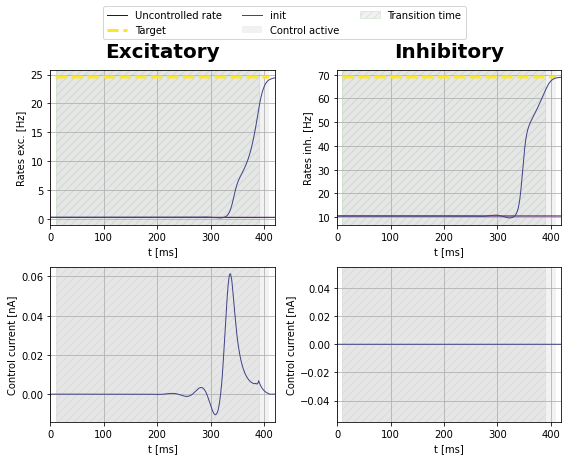

--------- 5


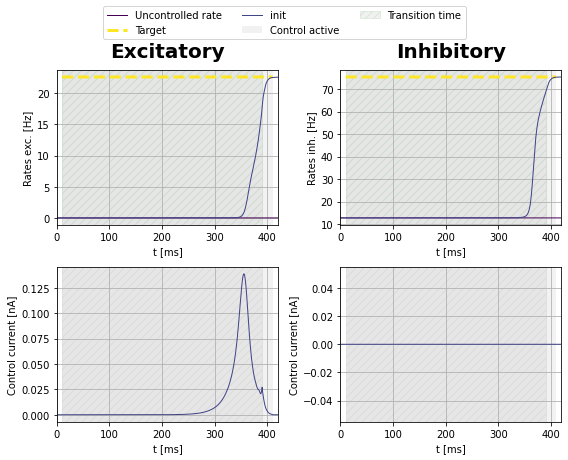

--------- 10


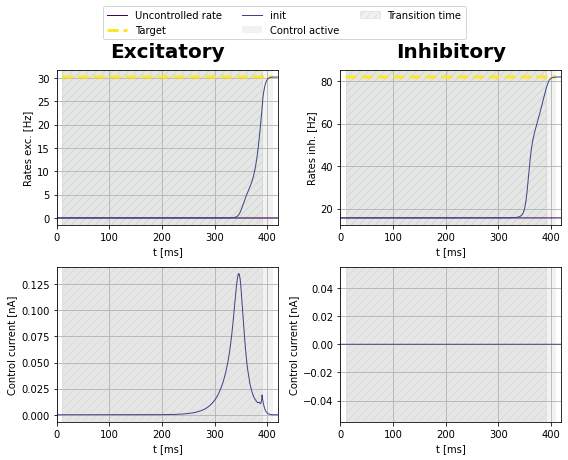

--------- 15


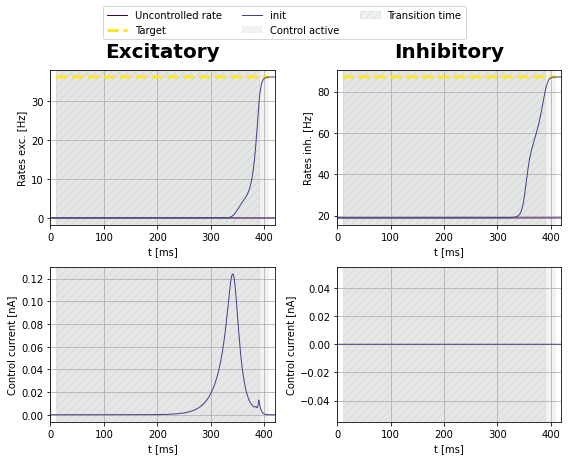

--------- 20


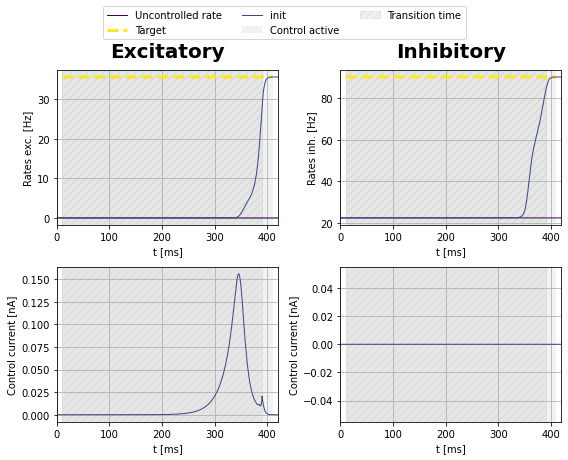

--------- 25


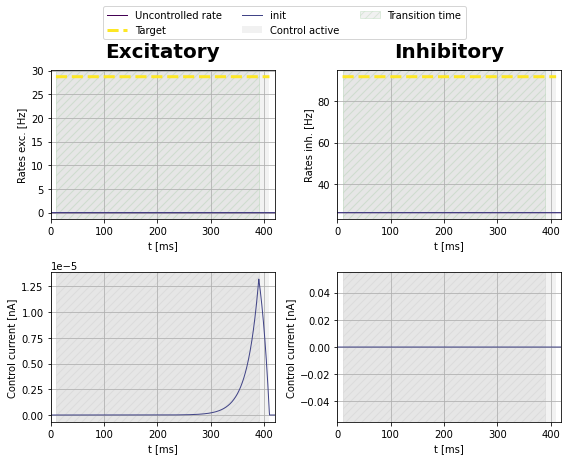

--------- 30


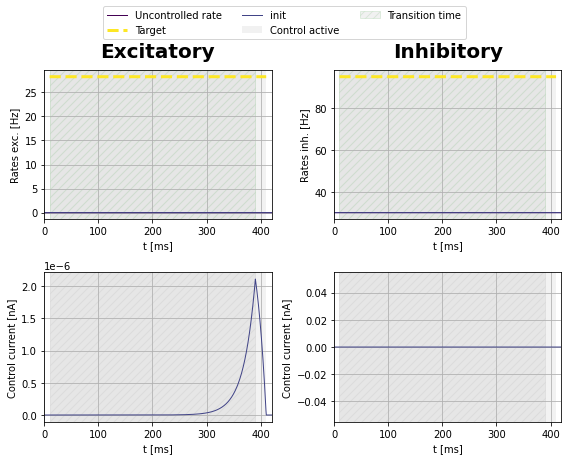

--------- 35


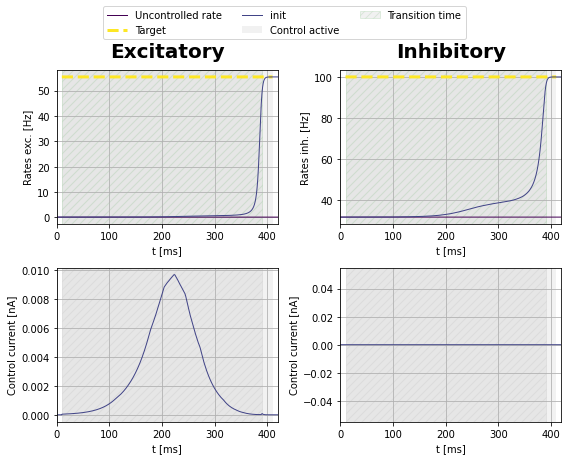

--------- 40


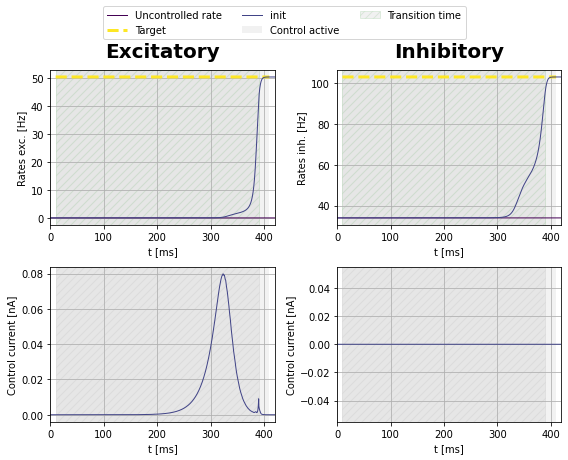

--------- 45


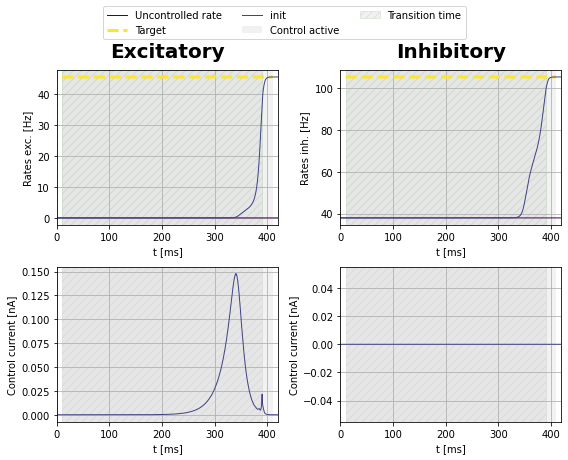

--------- 50


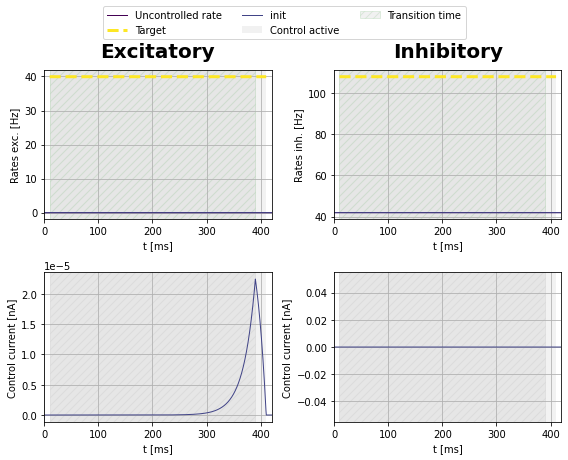

--------- 55


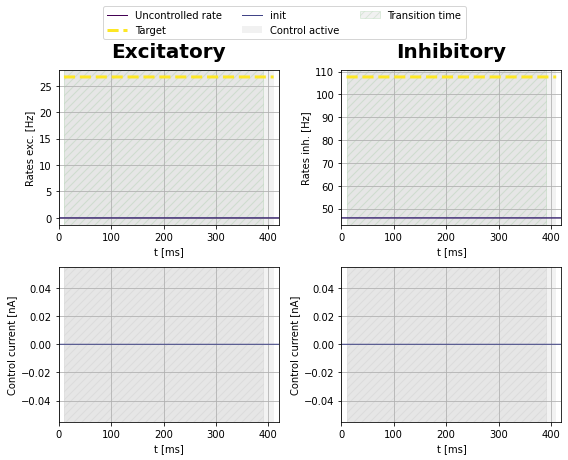

--------- 60


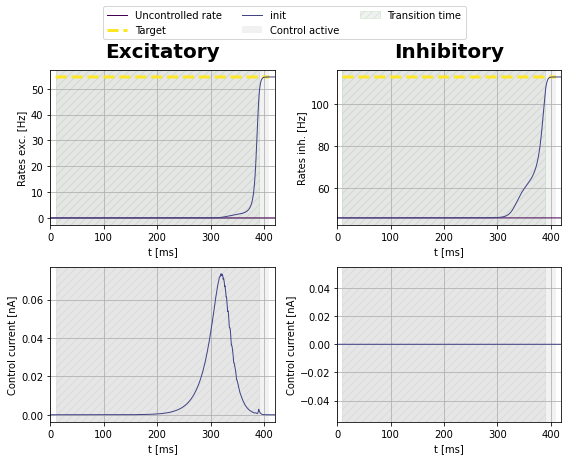

--------- 65


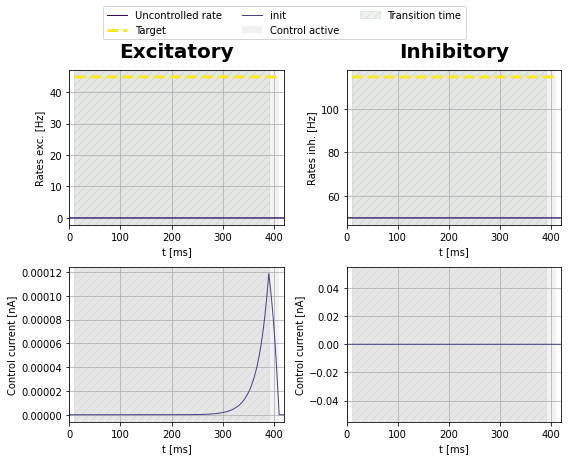

--------- 70


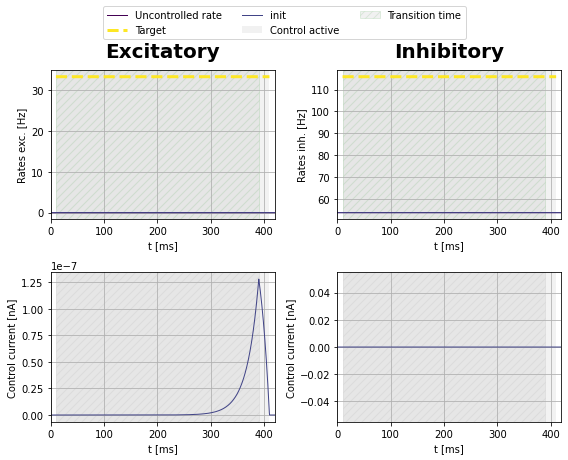

--------- 75


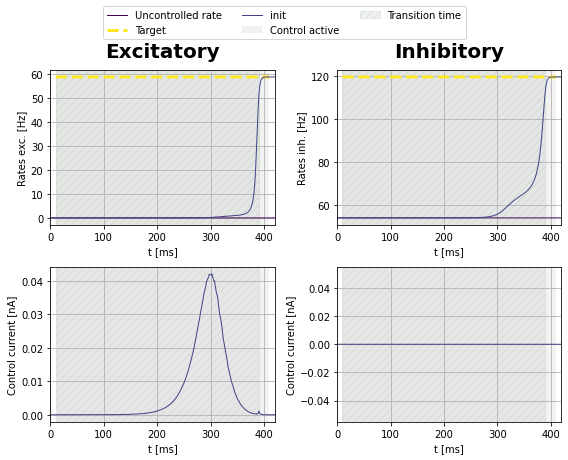

--------- 80


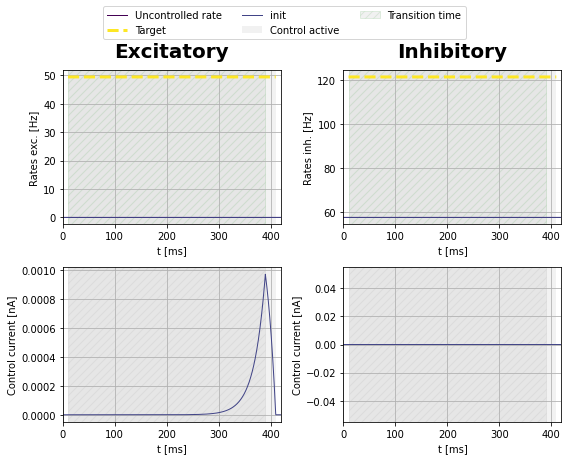

--------- 85


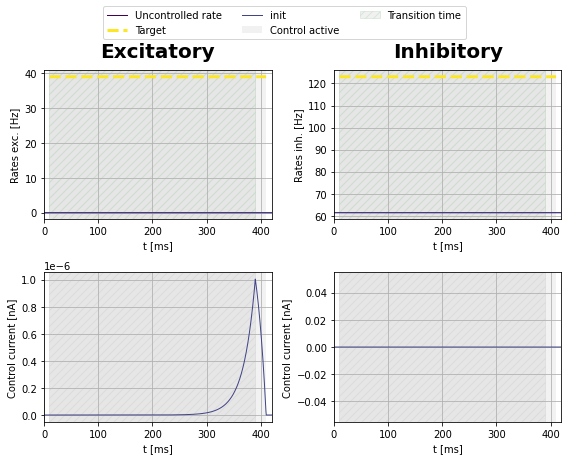

--------- 90


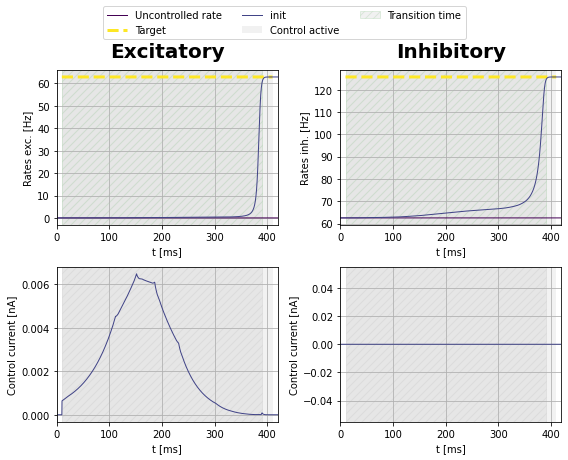

--------- 95


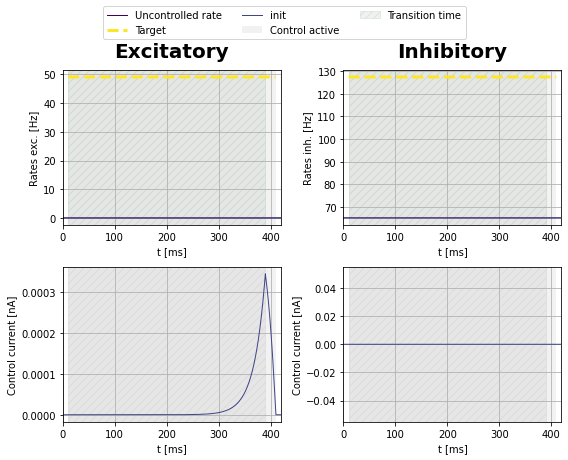

--------- 100


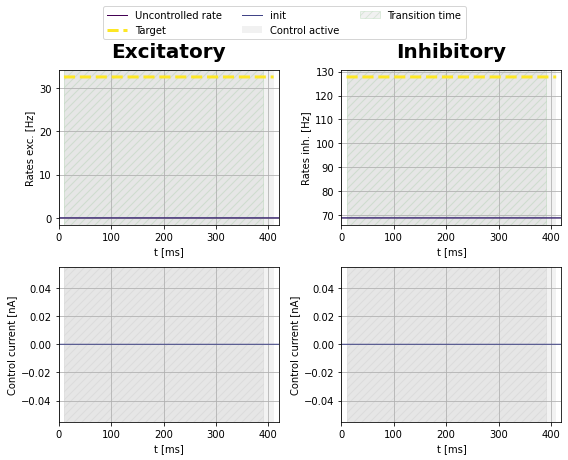

--------- 105


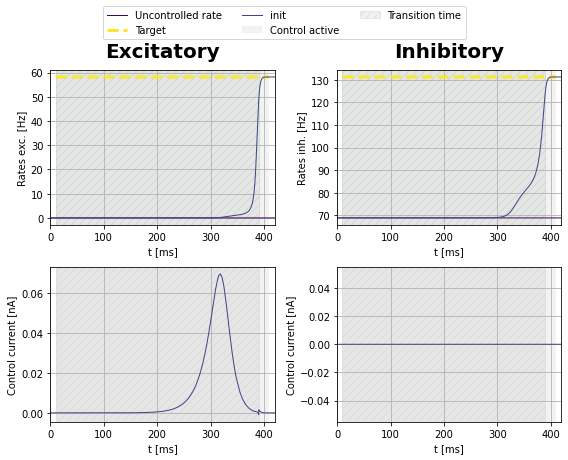

--------- 110


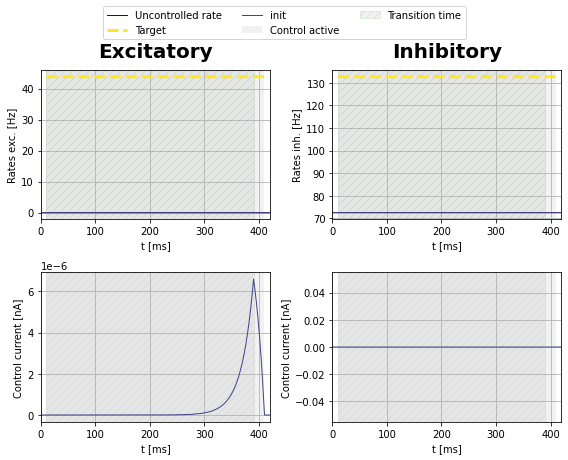

--------- 115


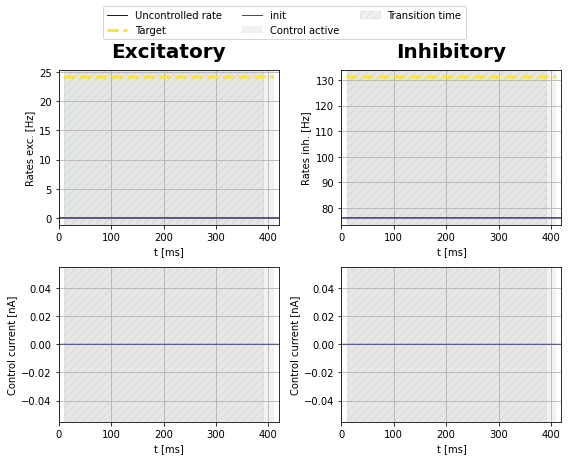

--------- 120


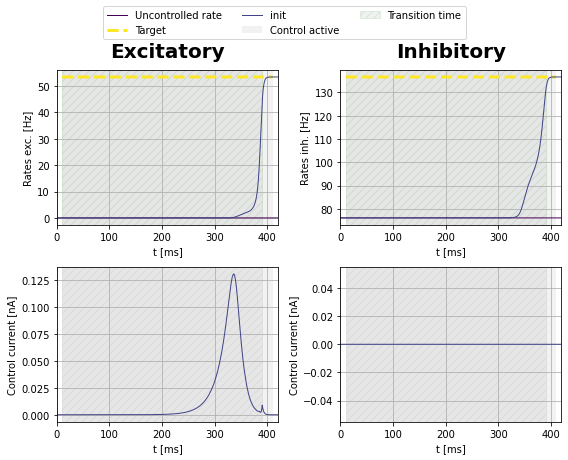

--------- 125


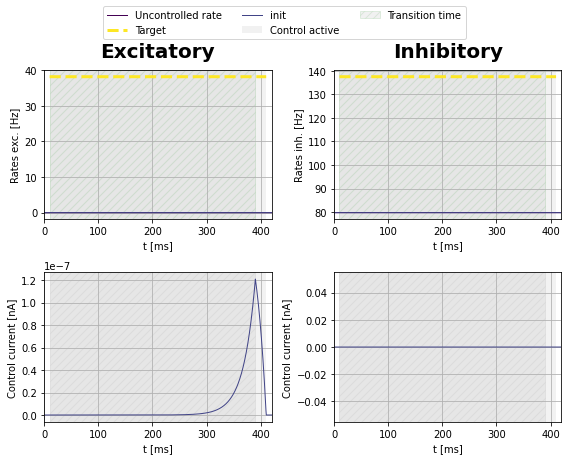

--------- 130


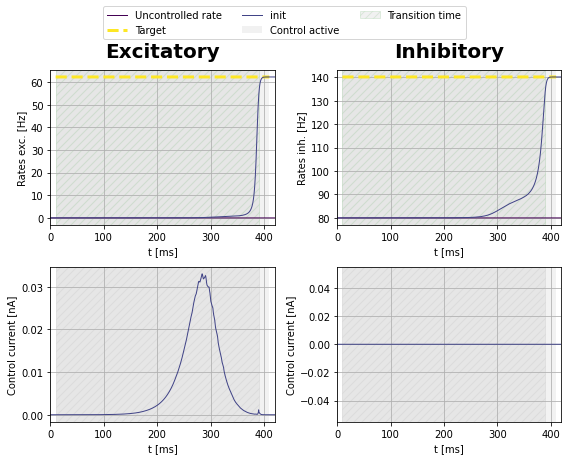

--------- 135


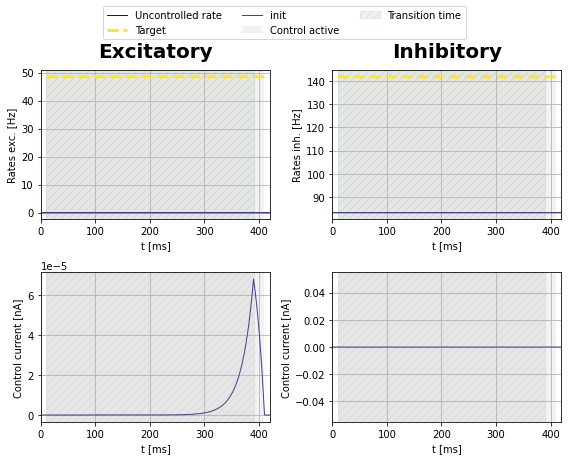

--------- 140


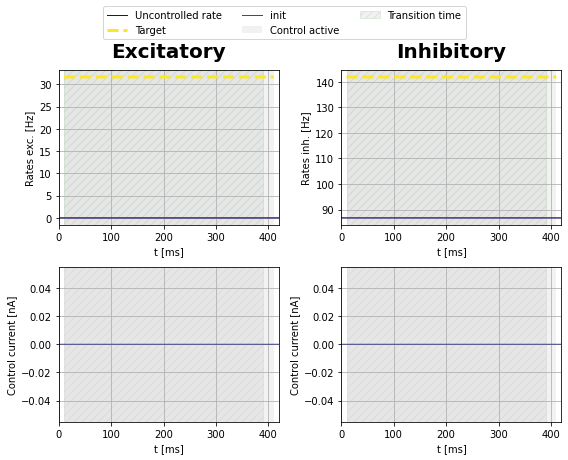

--------- 145


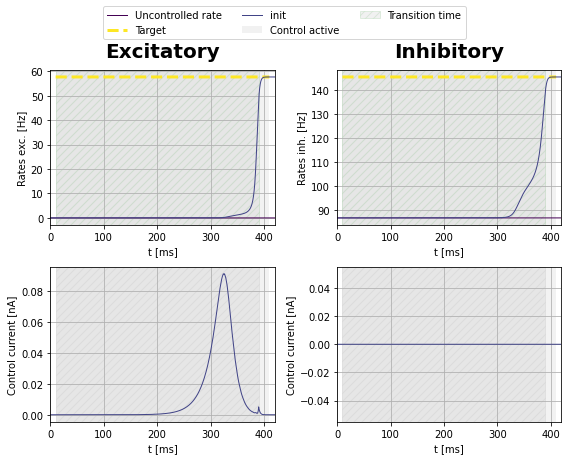

In [15]:

#plot initial guesses
for i in i_range:
    print("---------", i)
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
    plt.show()


In [16]:
found_solution = []
no_solution = []
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break


    for i in i_range:
        print("------- ", i, exc[i], inh[i])        

        if np.abs(np.mean(bestState_init[i][0,0,-300:]) - target[i][0,0,-1]) < 0.1 * np.abs(
            np.mean(bestState_init[i][0,0,-100:]) - bestState_init[i][0,0,0]) and np.abs(
            np.mean(bestState_init[i][0,1,-300:]) - target[i][0,1,-1]) < 0.1 * np.abs(
            np.mean(bestState_init[i][0,1,-100:]) - bestState_init[i][0,1,0]) and np.amax(
            bestState_init[i][0,0,:]) < target[i][0,0,-1] + 1. and np.amax(
            bestState_init[i][0,1,:]) < target[i][0,1,-1]:
            # and np.amin(bestState_init[i][0,0,:]) > bestState_init[i][0,0,0] - 1.
            #and np.amin(bestState_init[i][0,1,:]) > bestState_init[i][0,1,0] - 1.:
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        if len(found_solution) == 0:
            continue
            
        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(init_file,'wb') as f:
            pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                         costnode_init, weights_init], f)

------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  5 0.4000000000000001 0.40000000000000013
found solution for  5
-------  10 0.4250000000000001 0.42500000000000016
found solution for  10
-------  15 0.4500000000000001 0.4500000000000002
found solution for  15
-------  20 0.4500000000000001 0.4750000000000002
found solution for  20
-------  25 0.4250000000000001 0.5000000000000002
[0, 5, 10, 15, 20] []
closest index  20
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8303.497570057187
Gradient descend method:  None
RUN  1 , total integrated cost =  8231.923651940206
RUN  2 , total integrated cost =  238.23772321587893
RUN  3 , total integrated cost =  161.4440116811572
RUN  4 , total integrated cost =  

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  185 , total integrated cost =  148.98237904765355
Improved over  185  iterations in  13.397567760199308  seconds by  98.20578764802809  percent.
Problem in initial value trasfer:  Vmean_exc -56.63979133328249 -56.639791414940525
weight =  552.5423391738882
set cost params:  1.0 552.5423391738882 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8230.912073860614
Gradient descend method:  None
RUN  1 , total integrated cost =  8222.146908796069
RUN  2 , total integrated cost =  8222.137329591584
RUN  3 , total integrated cost =  8221.986293121232
RUN  4 , total integrated cost =  8221.893679785177
RUN  5 , total integrated cost =  8221.884908062348
RUN  6 , total integrated cost =  8221.602939160286
RUN  7 , total integrated cost =  8221.405232470932
RUN  8 , total integrated cost =  8221.39715054348
RUN  9 , total integrated cost =  8221.240587434499
RUN  10 , total integrated cost =  8221.159347018985
RUN  11 , total inte

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  53 , total integrated cost =  8216.896651095372
Improved over  53  iterations in  3.6313779670745134  seconds by  0.17027788220154605  percent.
Problem in initial value trasfer:  Vmean_exc -56.6398343349731 -56.63983214826872
-------  30 0.4250000000000001 0.5250000000000002
[0, 5, 10, 15, 20] []
closest index  20
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8049.928313311968
Gradient descend method:  None
RUN  1 , total integrated cost =  7978.334414393267
RUN  2 , total integrated cost =  7978.317185978744
RUN  3 , total integrated cost =  7978.317181775824
RUN  4 , total integrated cost =  7978.31718177475


...

RUN  6 , total integrated cost =  7978.317181774743
Control only changes marginally.
RUN  6 , total integrated cost =  7978.317181774743
Improved over  6  iterations in  0.5222230926156044  seconds by  0.07896439855885262  percent.
Problem in initial value trasfer:  Vmean_exc -76.60097381065552 -76.60097429447245
weight =  10.00000000001371
set cost params:  1.0 10.00000000001371 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7978.317181774743
Gradient descend method:  None
RUN  1 , total integrated cost =  7978.317181774743
Control only changes marginally.
RUN  1 , total integrated cost =  7978.317181774743
Improved over  1  iterations in  0.16154824942350388  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -76.60097381065552 -76.60097429447245
-------  35 0.5500000000000003 0.5250000000000002
-------  40 0.5250000000000001 0.5500000000000003
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.60000000

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  281 , total integrated cost =  178.01970762603153
Improved over  281  iterations in  19.73466314561665  seconds by  48.12044913886869  percent.
Problem in initial value trasfer:  Vmean_exc -56.63789071558588 -56.63789079864974
weight =  448.17044630507104
set cost params:  1.0 448.17044630507104 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7977.729062258235
Gradient descend method:  None
RUN  1 , total integrated cost =  7974.994522869268
RUN  2 , total integrated cost =  7974.992963606122
RUN  3 , total integrated cost =  7974.9925328780055
RUN  4 , total integrated cost =  7974.990562444034
RUN  5 , total integrated cost =  7974.969333281697
RUN  6 , total integrated cost =  7974.964095729904
RUN  7 , total integrated cost =  7974.963687740407
RUN  8 , total integrated cost =  7974.962509911992
RUN  9 , total integrated cost =  7974.917726906943
RUN  10 , total integrated cost =  7974.896519515245
RUN  11 , total in

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  177 , total integrated cost =  7973.532839506047
Improved over  177  iterations in  11.988330326974392  seconds by  0.052599213628852226  percent.
Problem in initial value trasfer:  Vmean_exc -56.63782756246989 -56.63782765312925
-------  35 0.5500000000000003 0.5250000000000002
-------  40 0.5250000000000001 0.5500000000000003
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0.6750000000000004
-------  80 0.5250000000000001 0.7000000000000004
-------  85 0.47500000000000014 0.7250000000000004
-------  90 0.6000000000000003 0.7250000000000004
-------  95 0.5250000000000001 0.7500000000000004
-------  100 0.4500000000000001 0.7750000000000005
-------  105 0.57500000000000

In [17]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [18]:
factor_iteration = 20
conv_0 = [[False]*2] * len(exc)
full_converge = False

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 20:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break
        
    counter += 1
    
    for i in i_range_0:
        print("------- ", i, exc[i], inh[i])
        
        if conv_0[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

    # exc and inh control current 

        setinit(initVars[i], aln)
        aln.params.duration = dur

        if not type(bestControl_0[i]) == type(None):
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
        else:
            control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
            weights_0[i] = weights_init[i]
            cost_0[i] = cost_init[i]

        cgv = None
        max_it = 500 * factor_iteration

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                           + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        with open(final_file,'wb') as f:
            pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                     costnode_0, weights_0], f)
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
weight =  7052.813223729279
set cost params:  1.0 7052.813223729279 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5894.920522495465
Gradient descend method:  None
RUN  1 , total integrated cost =  5789.1692357409165
RUN  2 , total integrated cost =  4753.3691658349735
RUN  3 , total integrated cost =  4685.199823111878
RUN  4 , total integrated cost =  4578.34027384824
RUN  5 , total integrated cost =  4524.92531469870

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  319 , total integrated cost =  2150.013964648372
Improved over  319  iterations in  47.1291436702013  seconds by  63.52768529374136  percent.
Problem in initial value trasfer:  Vmean_exc -56.627116678624496 -56.62712061814475
no convergence
-------  5 0.4000000000000001 0.40000000000000013
weight =  1031.4853362676404
set cost params:  1.0 1031.4853362676404 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5091.982199186547
Gradient descend method:  None
RUN  1 , total integrated cost =  5068.415546391547
RUN  2 , total integrated cost =  5038.740128236868
RUN  3 , total integrated cost =  5015.156503526494
RUN  4 , total integrated cost =  4981.788795110501
RUN  5 , total integrated cost =  4958.344157894314
RUN  6 , total integrated cost =  4927.054309222731
RUN  7 , total integrated cost =  4903.651093417348
RUN  8 , total integrated cost =  4872.823264486604
RUN  9 , total integrated cost =  4850.047232679277
RUN  10 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  469 , total integrated cost =  1889.4135665667645
Improved over  469  iterations in  72.892034702003  seconds by  62.8943406976442  percent.
Problem in initial value trasfer:  Vmean_exc -56.6244803151348 -56.62447891513797
no convergence
-------  10 0.4250000000000001 0.42500000000000016
weight =  1854.5208034520847
set cost params:  1.0 1854.5208034520847 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9105.643743529708
Gradient descend method:  None
RUN  1 , total integrated cost =  9061.472032923639
RUN  2 , total integrated cost =  8959.009395973664
RUN  3 , total integrated cost =  8618.76569815055
RUN  4 , total integrated cost =  5987.751636912006
RUN  5 , total integrated cost =  5856.507931161158
RUN  6 , total integrated cost =  5824.031665558028
RUN  7 , total integrated cost =  5802.145029095084
RUN  8 , total integrated cost =  5760.532659026117
RUN  9 , total integrated cost =  5739.941356797422
RUN  10 , t

...

RUN  1 , total integrated cost =  7968.117989728056
Control only changes marginally.
RUN  1 , total integrated cost =  7968.117989728056
Improved over  1  iterations in  0.46643603406846523  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.637763997593154 -56.63776567299958
converged for  30
-------  35 0.5500000000000003 0.5250000000000002
-------  40 0.5250000000000001 0.5500000000000003
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0.6750000000000004
-------  80 0.5250000000000001 0.7000000000000004
-------  85 0.47500000000000014 0.7250000000000004
-------  90 0.6000000000000003 0.7250000000000004
-------  95 0.5250000000000001 0.7500000000000004
-------  100 0.45000000000000

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  9109.484440767426
Control only changes marginally.
RUN  1 , total integrated cost =  9109.484440767426
Improved over  1  iterations in  0.5855575166642666  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64601829340997 -56.64602528969296
converged for  10
-------  15 0.4500000000000001 0.4500000000000002
-------  20 0.4500000000000001 0.4750000000000002
-------  25 0.4250000000000001 0.5000000000000002
-------  30 0.4250000000000001 0.5250000000000002
weight =  781.2499210437177
set cost params:  1.0 781.2499210437177 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  7968.117989728057
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  7968.117989728057
Control only changes marginally.
RUN  1 , total integrated cost =  7968.117989728057
Improved over  1  iterations in  0.5654313880950212  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.637763997593154 -56.63776567299958
converged for  30
-------  35 0.5500000000000003 0.5250000000000002
-------  40 0.5250000000000001 0.5500000000000003
-------  45 0.5000000000000002 0.5750000000000003
-------  50 0.47500000000000014 0.6000000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  60 0.5500000000000003 0.6250000000000003
-------  65 0.5000000000000002 0.6500000000000004
-------  70 0.4500000000000001 0.6750000000000004
-------  75 0.5750000000000002 0.6750000000000004
-------  80 0.5250000000000001 0.7000000000000004
-------  85 0.47500000000000014 0.7250000000000004
-------  90 0.6000000000000003 0.7250000000000004
-------  95 0.5250000000000001 0.7500000000000004
-------  100 0.450000000000000

In [19]:
"""
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)
"""

'\nfor i in i_range_0:\n    \n    aln.params.mue_ext_mean = exc[i] * 5.\n    aln.params.mui_ext_mean = inh[i] * 5.\n\n    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],\n        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,\n        dur_pre, dur_post, initVars[i], target[i], \'\', filename_ = \'\', transition_time_ = trans_time,\n        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)\n'

In [20]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [ ]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    if counter > 20:
        break
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        
        if conv_1[i] == [True, True]:
            continue
            
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        if not type(bestControl_1[i]) == type(None):
            control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1].copy()
        else:
            control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1].copy()
            cost_1[i] = cost_0[i]
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        with open(final_file_1,'wb') as f:
            pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)
            
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
    counter += 1

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  74.95082177759093
Gradient descend method:  None
RUN  1 , total integrated cost =  0.6531469418378986
RUN  2 , total integrated cost =  0.3584373066565006
RUN  3 , total integrated cost =  0.34838899926322864
RUN  4 , total integrated cost =  0.3418105541172187
RUN  5 , total integrated cost =  0.3375688946248359
RUN  6 , total integrated cost =  0

ERROR:root:Problem in initial value trasfer


State only changes marginally.
Control only changes marginally.
RUN  310 , total integrated cost =  1.9999435124798381
Improved over  310  iterations in  21.126722583547235  seconds by  96.0300291126618  percent.
Problem in initial value trasfer:  Vmean_exc -56.646509360964615 -56.646509373958466
no convergence
-------  15 0.4500000000000001 0.4500000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  46.97849683452959
Gradient descend method:  None
RUN  1 , total integrated cost =  2.5153263824151595
RUN  2 , total integrated cost =  2.204967250859862
RUN  3 , total integrated cost =  2.177408637710552
RUN  4 , total integrated cost =  2.164630798603084
RUN  5 , total integrated cost =  2.1578002511668433
RUN  6 , total integrated cost =  2.152905375905533
RUN  7 , total integrated cost =  2.1479810180491534
RUN  8 , total integrated cost =  2.1445235631244635
RUN  9 , total integrated cost =  2.141258394470201
RUN  10 , tota

no convergence
-------  30 0.4250000000000001 0.5250000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14.879290629805858
Gradient descend method:  None
RUN  1 , total integrated cost =  10.727962365767292
RUN  2 , total integrated cost =  10.520022734452136
RUN  3 , total integrated cost =  10.429725992098552
RUN  4 , total integrated cost =  10.39973620360331
RUN  5 , total integrated cost =  10.376132454076798
RUN  6 , total integrated cost =  10.36656642915484
RUN  7 , total integrated cost =  10.358072956333228
RUN  8 , total integrated cost =  10.356103852433622
RUN  9 , total integrated cost =  10.354104706543172
RUN  10 , total integrated cost =  10.352700734130382
RUN  11 , total integrated cost =  10.351223630098412
RUN  12 , total integrated cost =  10.350196953711698
RUN  13 , total integrated cost =  10.348987822794376
RUN  14 , total integrated cost =  10.348084583000425
RUN  15 , total integrated cost =  10.

RUN  160 , total integrated cost =  2.0746094426660986
RUN  170 , total integrated cost =  2.074607657847396
RUN  180 , total integrated cost =  2.074603484521725
RUN  190 , total integrated cost =  2.074599650197886
RUN  200 , total integrated cost =  2.0745975490107744
RUN  300 , total integrated cost =  2.074447647723081
RUN  400 , total integrated cost =  2.073930040770518
RUN  500 , total integrated cost =  2.073766321404332
RUN  600 , total integrated cost =  2.073694683183449
RUN  700 , total integrated cost =  2.0736847844606707
Control only changes marginally.
RUN  707 , total integrated cost =  2.073684784460579
Improved over  707  iterations in  48.95723758637905  seconds by  95.49711337566022  percent.
no convergence
-------  45 0.5000000000000002 0.5750000000000003
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  48.79162611271003
Gradient descend method:  None
RUN  1 , total integrated cost =  6.270588164246816
RUN  2 ,

...

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  425 , total integrated cost =  9.5907095625004
Improved over  425  iterations in  29.205297926440835  seconds by  74.35961028468546  percent.
Problem in initial value trasfer:  Vmean_exc -56.69518310778834 -56.695183152185564
no convergence
-------  70 0.4500000000000001 0.6750000000000004
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  26.95868104649076
Gradient descend method:  None
RUN  1 , total integrated cost =  23.316890815564708
RUN  2 , total integrated cost =  23.301079521952495
RUN  3 , total integrated cost =  23.28744351323339
RUN  4 , total integrated cost =  23.26269234360127
RUN  5 , total integrated cost =  23.241462954371663
RUN  6 , total integrated cost =  23.20490946822685
RUN  7 , total integrated cost =  23.172132197365837
RUN  8 , total integrated cost =  22.66278143689929
RUN  9 , total integrated cost =  22.32661147099687
RUN  10 , total integrated cost =  22.3042924331

RUN  11 , total integrated cost =  7.3273521376818
RUN  12 , total integrated cost =  7.320059078796538
RUN  13 , total integrated cost =  7.312749265885216
RUN  14 , total integrated cost =  7.306065667374651
RUN  15 , total integrated cost =  7.299619471497067
RUN  16 , total integrated cost =  7.293564559328885
RUN  17 , total integrated cost =  7.287003935755695
RUN  18 , total integrated cost =  7.281073433847853
RUN  19 , total integrated cost =  7.2742395834228315
RUN  20 , total integrated cost =  7.268253819854077
RUN  30 , total integrated cost =  7.180673343346546
RUN  40 , total integrated cost =  7.176889108616911
RUN  50 , total integrated cost =  7.173276540399536
RUN  60 , total integrated cost =  7.164078512427993
RUN  70 , total integrated cost =  7.163099001942875
RUN  80 , total integrated cost =  7.162345496298206
RUN  90 , total integrated cost =  7.158731406725217
RUN  100 , total integrated cost =  7.157964443182665
RUN  110 , total integrated cost =  7.15753969

RUN  700 , total integrated cost =  0.05108410913172606
RUN  800 , total integrated cost =  0.05106971021667089
RUN  900 , total integrated cost =  0.051069191084097666
RUN  1000 , total integrated cost =  0.05106780626297267
RUN  1100 , total integrated cost =  0.051067476028665015
RUN  1200 , total integrated cost =  0.051067463977828256
RUN  1300 , total integrated cost =  0.0510674526367796
RUN  1400 , total integrated cost =  0.05106744060604247
RUN  1500 , total integrated cost =  0.05106742861276857
RUN  1600 , total integrated cost =  0.05106740351299045
RUN  1700 , total integrated cost =  0.05106726767779868
RUN  1800 , total integrated cost =  0.05106724960303683
RUN  1900 , total integrated cost =  0.05106723041933189
RUN  2000 , total integrated cost =  0.05106721272307631
RUN  3000 , total integrated cost =  0.051066004751231325
RUN  4000 , total integrated cost =  0.05106518605588158
State only changes marginally.
State only changes marginally.
Control only changes margi

RUN  30 , total integrated cost =  2.05865813532136
RUN  40 , total integrated cost =  2.0581040870582767
RUN  50 , total integrated cost =  2.0557007304731054
RUN  60 , total integrated cost =  2.0554721271987613
RUN  70 , total integrated cost =  2.0553209104520542
RUN  80 , total integrated cost =  2.055221977151008
RUN  90 , total integrated cost =  2.0551228423877452
RUN  100 , total integrated cost =  2.0540326854635484
RUN  110 , total integrated cost =  2.052793120836325
RUN  120 , total integrated cost =  2.052766751579072
RUN  130 , total integrated cost =  2.0527424500991645
RUN  140 , total integrated cost =  2.0522755421081857
RUN  150 , total integrated cost =  2.0519540635887608
RUN  160 , total integrated cost =  2.0519365842340744
RUN  170 , total integrated cost =  2.0519298951407725
RUN  180 , total integrated cost =  2.0519157035598212
RUN  190 , total integrated cost =  2.051880930869164
RUN  200 , total integrated cost =  2.051870487468061
RUN  300 , total integra